# Retail Demand Forecasting & Decision Support System

### An End-to-End Data Science Solution for Daily Retail Sales Prediction

---

**Author:** ShawRick (Associate Data Analyst)

**Project Type:** End-to-End Machine Learning Portfolio

**Industry:** Retail Analytics

**Dataset:** Corporación Favorita Grocery Sales Forecasting

**Tools & Technologies**

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- XGBoost
- LightGBM
- Streamlit

---

> This project demonstrates the complete data science lifecycle, from business understanding and exploratory data analysis to machine learning model development and deployment through an interactive dashboard.

### Business Understanding:
**Objective**:
- Forecast retail demand to improve inventory planning and support business decision-making.

### Project Overview:

| Item         | Details                                                          |
| ------------ | ---------------------------------------------------------------- |
| Project      | Retail Demand Forecasting & Decision Support System              |
| Company      | ABC Retail Group                                                 |
| Domain       | Retail Analytics                                                 |
| Project Type | Business Intelligence + Machine Learning                         |
| Duration     | Historical Analysis + 12-Month Forecast                          |
| Primary Goal | Support business decision making using analytics and forecasting |

### Business Questions:

| Business Area | Key Questions                                       |
| ------------- | --------------------------------------------------- |
| Sales         | How are sales changing over time?                   |
| Products      | Which product families drive revenue?               |
| Stores        | Which stores perform best and worst?                |
| Promotions    | Which promotions increase sales?                    |
| Holidays      | How do holidays affect demand?                      |
| Economy       | Does oil price influence sales?                     |
| Forecasting   | What is the expected demand for the next 12 months? |
| Inventory     | How much inventory should be replenished?           |

### Exploratory Data Analysis (EDA):

| Category    | Business Questions                                 |
| ----------- | -------------------------------------------------- |
| Sales Trend | How has sales changed over time?                   |
| Products    | Which product families generate the highest sales? |
| Stores      | Which stores contribute the most revenue?          |
| Geography   | Which cities and states perform best?              |
| Promotions  | Do promotions increase sales?                      |
| Holidays    | Which holidays significantly affect demand?        |
| Seasonality | Which months and weekdays have peak demand?        |
| Economy     | Does oil price influence sales performance?        |

### Statistical Analysis:

| Category      | Business Questions                                 |
| ------------- | -------------------------------------------------- |
| Sales         | What is the average daily sales volume?            |
| Distribution  | Is sales data normally distributed?                |
| Variability   | How stable are daily sales?                        |
| Outliers      | Which observations require business investigation? |
| Relationships | Which variables influence sales?                   |
| Target        | Is the sales variable suitable for forecasting?    |

### Feature Engineering:

| Category          | Business Questions                                      |
| ----------------- | ------------------------------------------------------- |
| Seasonality       | How do weekdays and months influence demand?            |
| Historical Demand | How does previous sales affect future sales?            |
| Promotions        | Can promotions improve forecast accuracy?               |
| Holidays          | Should holidays be included in forecasting?             |
| Economy           | Does oil price improve demand prediction?               |
| Stores            | Do different stores require separate behavior patterns? |

In [9]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [10]:
from src.analysis.audit import *
from src.config import *

In [11]:
datasets = load_datasets(RAW_DATA_DIR)

In [12]:
run_data_audit(datasets)


DATASET INVENTORY
    Dataset     Rows  Columns  Memory (MB)
0     train  3000888        6       431.45
1      test    28512        5         3.88
2    stores       54        5         0.01
3       oil     1218        2         0.08
4  holidays      350        6         0.10

DATASET INFORMATION
    Dataset     Rows  Columns  Numeric  Categorical  Datetime  Memory (MB)
0     train  3000888        6        4            2         0       431.45
1      test    28512        5        3            2         0         3.88
2    stores       54        5        2            3         0         0.01
3       oil     1218        2        1            1         0         0.08
4  holidays      350        6        0            5         0         0.10

MISSING VALUE SUMMARY
  Dataset      Column  Missing  Missing (%)
0     oil  dcoilwtico       43         3.53

DUPLICATE SUMMARY
    Dataset  Duplicate Rows  Duplicate (%)
0     train               0            0.0
1      test               0         

In [13]:
from src.analysis.eda import *

In [14]:
daily = daily_sales_trend(datasets["train"])

daily.head()

,date,total_sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [15]:
weekly = weekly_sales_trend(datasets["train"])

weekly.head()

,date,total_sales
0,2013-01-06,2.211570e+06
1,2013-01-13,2.373618e+06
2,2013-01-20,2.368007e+06
3,2013-01-27,2.272165e+06
4,2013-02-03,2.476891e+06


In [16]:
monthly = monthly_sales_trend(datasets["train"])

monthly.head()

,date,total_sales
0,2013-01-31,1.032762e+07
1,2013-02-28,9.658960e+06
2,2013-03-31,1.142850e+07
3,2013-04-30,1.099346e+07
4,2013-05-31,1.159770e+07


In [17]:
yearly = yearly_sales_trend(datasets["train"])

yearly.head()

,date,total_sales
0,2013-12-31,1.404190e+08
1,2014-12-31,2.094742e+08
2,2015-12-31,2.408801e+08
3,2016-12-31,2.886545e+08
4,2017-12-31,1.942171e+08


In [18]:
sales_summary(datasets["train"])

,Metric
Total Sales,1.073645e+09
Average Daily Sales,6.375564e+05
Maximum Daily Sales,1.463084e+06
Minimum Daily Sales,2.511619e+03
Transactions,3.000888e+06
Stores,5.400000e+01
Families,3.300000e+01


In [19]:
sales_growth(datasets["train"])

,date,sales,growth_pct
0,2013-01-31,1.032762e+07,NaN
1,2013-02-28,9.658960e+06,-6.474528
2,2013-03-31,1.142850e+07,18.320164
3,2013-04-30,1.099346e+07,-3.806557
4,2013-05-31,1.159770e+07,5.496350
5,2013-06-30,1.168934e+07,0.790157
6,2013-07-31,1.125740e+07,-3.695190
7,2013-08-31,1.173779e+07,4.267311
8,2013-09-30,1.179293e+07,0.469802
9,2013-10-31,1.177562e+07,-0.146807


In [20]:
product_family_analysis(datasets["train"]).head()

,family,total_sales
12,GROCERY I,3.434627e+08
3,BEVERAGES,2.169545e+08
30,PRODUCE,1.227047e+08
7,CLEANING,9.752129e+07
8,DAIRY,6.448771e+07


In [21]:
top_product_families(datasets["train"])

,family,total_sales
12,GROCERY I,3.434627e+08
3,BEVERAGES,2.169545e+08
30,PRODUCE,1.227047e+08
7,CLEANING,9.752129e+07
8,DAIRY,6.448771e+07
5,BREAD/BAKERY,4.213395e+07
28,POULTRY,3.187600e+07
24,MEATS,3.108647e+07
25,PERSONAL CARE,2.459205e+07
9,DELI,2.411032e+07


In [22]:
store_performance(datasets["train"]).head()

,store_nbr,total_sales
43,44,6.208755e+07
44,45,5.449801e+07
46,47,5.094831e+07
2,3,5.048191e+07
48,49,4.342010e+07


In [23]:
top_stores(datasets["train"])

,store_nbr,total_sales
43,44,6.208755e+07
44,45,5.449801e+07
46,47,5.094831e+07
2,3,5.048191e+07
48,49,4.342010e+07
45,46,4.189606e+07
47,48,3.593313e+07
50,51,3.291149e+07
7,8,3.049429e+07
49,50,2.865302e+07


In [24]:
store_type_analysis(
    datasets["train"],
    datasets["stores"]
)

,type,total_sales
0,A,3.530438e+08
3,D,3.510833e+08
2,C,1.644347e+08
1,B,1.452606e+08
4,E,5.982244e+07


In [25]:
cluster_analysis(
    datasets["train"],
    datasets["stores"]
)

,cluster,total_sales
13,14,1.574305e+08
5,6,1.142544e+08
7,8,1.079282e+08
10,11,1.006143e+08
9,10,8.532443e+07
2,3,7.562870e+07
12,13,7.210225e+07
4,5,6.208755e+07
14,15,5.529695e+07
0,1,5.437675e+07


In [26]:
city_analysis(
    datasets["train"],
    datasets["stores"]
)

,city,total_sales
18,Quito,5.567418e+08
8,Guayaquil,1.229673e+08
3,Cuenca,4.916860e+07
0,Ambato,4.030440e+07
21,Santo Domingo,3.583432e+07
13,Machala,3.338680e+07
2,Cayambe,2.832556e+07
10,Latacunga,2.118226e+07
4,Daule,1.918802e+07
12,Loja,1.886000e+07


In [27]:
state_analysis(
    datasets["train"],
    datasets["stores"]
)

,state,total_sales
12,Pichincha,5.850674e+08
6,Guayas,1.651544e+08
0,Azuay,4.916860e+07
15,Tungurahua,4.030440e+07
14,Santo Domingo de los Tsachilas,3.583432e+07
4,El Oro,3.338680e+07
9,Los Rios,3.192537e+07
10,Manabi,2.496982e+07
3,Cotopaxi,2.118226e+07
8,Loja,1.886000e+07


In [28]:
stores_per_city(
    datasets["stores"]
)

,city,store_count
18,Quito,18
8,Guayaquil,8
21,Santo Domingo,3
3,Cuenca,3
14,Manta,2
13,Machala,2
10,Latacunga,2
0,Ambato,2
7,Guaranda,1
9,Ibarra,1


In [29]:
stores_per_state(
    datasets["stores"]
)

,state,store_count
12,Pichincha,19
6,Guayas,11
0,Azuay,3
10,Manabi,3
14,Santo Domingo de los Tsachilas,3
3,Cotopaxi,2
4,El Oro,2
9,Los Rios,2
15,Tungurahua,2
1,Bolivar,1


In [30]:
stores_per_state(
    datasets["stores"]
)

,state,store_count
12,Pichincha,19
6,Guayas,11
0,Azuay,3
10,Manabi,3
14,Santo Domingo de los Tsachilas,3
3,Cotopaxi,2
4,El Oro,2
9,Los Rios,2
15,Tungurahua,2
1,Bolivar,1


In [31]:
promotion_analysis(
    datasets["train"]
)

,promotion_flag,total_sales,average_sales,total_transactions,promoted_items
0,False,3.781398e+08,158.246681,2389559,0
1,True,6.955052e+08,1137.693730,611329,7810622


In [32]:
holiday_analysis(
    datasets["train"],
    datasets["holidays"]
)

,holiday,total_sales,average_sales,observations
0,False,8.986482e+08,352.159181,2551824
1,True,1.979265e+08,393.864762,502524


In [33]:
oil_price_analysis(
    datasets["train"],
    datasets["oil"]
).head()

,date,total_sales,oil_price
0,2013-01-01,2511.618999,93.14
1,2013-01-02,496092.417944,93.14
2,2013-01-03,361461.231124,92.97
3,2013-01-04,354459.677093,93.12
4,2013-01-05,477350.121229,93.12


In [34]:
sales_distribution(
    datasets["train"]
)

,Metric
Minimum,0.000000e+00
Maximum,1.247170e+05
Mean,3.577757e+02
Median,1.100000e+01
Standard Deviation,1.101998e+03
Variance,1.214399e+06
Skewness,7.358758e+00
Kurtosis,1.545621e+02
Zero Sales,9.391300e+05
Zero Sales (%),3.130000e+01


In [35]:
corr = correlation_analysis(
    datasets["train"]
)

corr

,id,store_nbr,sales,onpromotion
id,1.000000,0.000301,0.085784,0.206260
store_nbr,0.000301,1.000000,0.041196,0.007286
sales,0.085784,0.041196,1.000000,0.427923
onpromotion,0.206260,0.007286,0.427923,1.000000


In [36]:
weekday_analysis(
    datasets["train"]
)

,weekday,total_sales
1,Monday,1.488278e+08
5,Tuesday,1.379221e+08
6,Wednesday,1.423787e+08
4,Thursday,1.212646e+08
0,Friday,1.390978e+08
2,Saturday,1.861015e+08
3,Sunday,1.980523e+08


In [37]:
weekend_analysis(
    datasets["train"]
)

,is_weekend,total_sales,average_sales
0,False,6.894911e+08,321.629081
1,True,3.841539e+08,448.179995


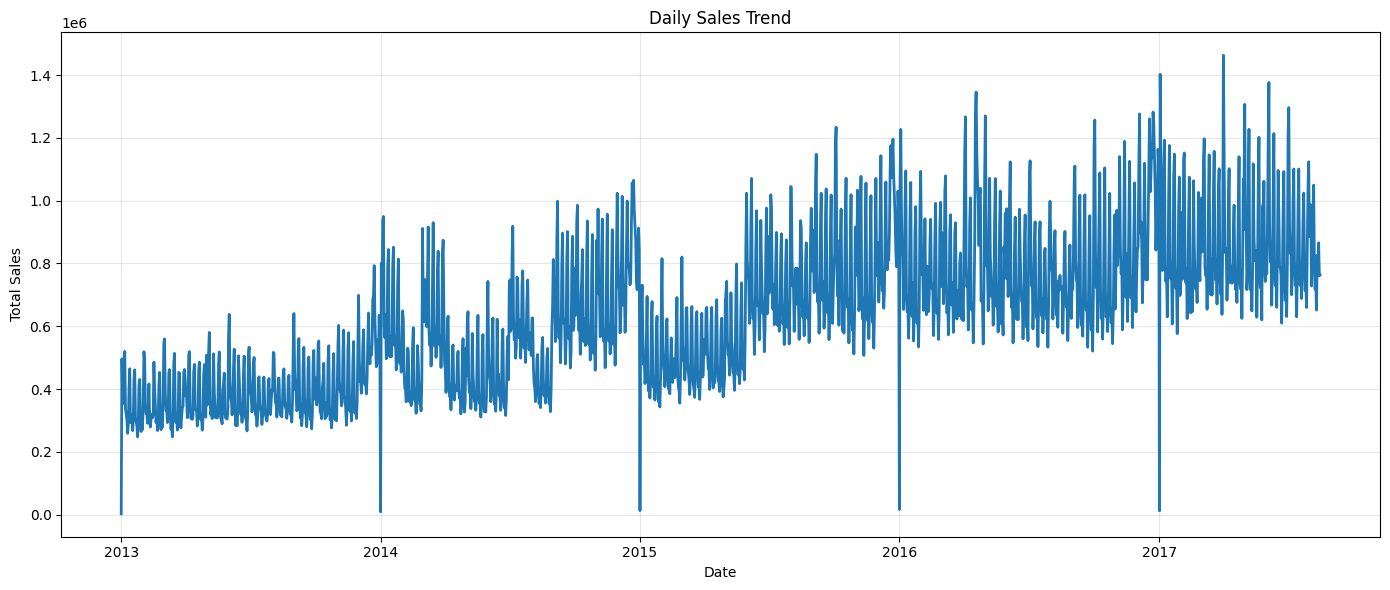

In [38]:
plot_sales_trend(
    daily,
    title="Daily Sales Trend"
)

In [39]:
run_eda(
    train=datasets["train"],
    stores=datasets["stores"],
    holidays=datasets["holidays"],
    oil=datasets["oil"]
)


SALES SUMMARY
                           Metric
Total Sales          1.073645e+09
Average Daily Sales  6.375564e+05
Maximum Daily Sales  1.463084e+06
Minimum Daily Sales  2.511619e+03
Transactions         3.000888e+06
Stores               5.400000e+01
Families             3.300000e+01

PRODUCT PERFORMANCE
           family   total_sales
12      GROCERY I  3.434627e+08
3       BEVERAGES  2.169545e+08
30        PRODUCE  1.227047e+08
7        CLEANING  9.752129e+07
8           DAIRY  6.448771e+07
5    BREAD/BAKERY  4.213395e+07
28        POULTRY  3.187600e+07
24          MEATS  3.108647e+07
25  PERSONAL CARE  2.459205e+07
9            DELI  2.411032e+07

STORE PERFORMANCE
    store_nbr   total_sales
43         44  6.208755e+07
44         45  5.449801e+07
46         47  5.094831e+07
2           3  5.048191e+07
48         49  4.342010e+07
45         46  4.189606e+07
47         48  3.593313e+07
50         51  3.291149e+07
7           8  3.049429e+07
49         50  2.865302e+07

SALES DISTRI

In [40]:
from src.analysis.statistics import *

In [41]:
descriptive_statistics(datasets["train"])

,sales
Count,3.000888e+06
Mean,3.577757e+02
Median,1.100000e+01
Mode,0.000000e+00
Minimum,0.000000e+00
Maximum,1.247170e+05
Range,1.247170e+05
Variance,1.214399e+06
Standard Deviation,1.101998e+03
Skewness,7.358758e+00


In [42]:
zero_sales_statistics(datasets["train"])

,Sales
Total Observations,3000888.0
Zero Sales,939130.0
Zero Sales (%),31.3
Non-Zero Sales,2061758.0


In [43]:
outlier_statistics(datasets["train"])

,sales
Lower Bound,-293.770875
Upper Bound,489.618125
Outliers,447105.000000
Outlier (%),14.900000


In [44]:
corr = correlation_matrix(datasets["train"])

corr

,id,store_nbr,sales,onpromotion
id,1.000000,0.000301,0.085784,0.206260
store_nbr,0.000301,1.000000,0.041196,0.007286
sales,0.085784,0.041196,1.000000,0.427923
onpromotion,0.206260,0.007286,0.427923,1.000000


In [45]:
covariance_matrix(datasets["train"])

,id,store_nbr,sales,onpromotion
id,7.504443e+11,4068.473578,8.189258e+07,2.183263e+06
store_nbr,4.068474e+03,242.916748,7.075629e+02,1.387485e+00
sales,8.189258e+07,707.562871,1.214399e+06,5.762063e+03
onpromotion,2.183263e+06,1.387485,5.762063e+03,1.493011e+02


In [46]:
sales_by_store_statistics(datasets["train"]).head()

,store_nbr,Total_Sales,Average_Sales,Median_Sales,Std_Sales,Min_Sales,Max_Sales,Transactions
0,1,1.414501e+07,254.534889,19.000,596.827146,0.0,9065.00,55572
1,2,2.155739e+07,387.918172,23.217,1079.560490,0.0,124717.00,55572
2,3,5.048191e+07,908.405495,64.000,2146.185033,0.0,21858.00,55572
3,4,1.890970e+07,340.273886,19.000,801.128208,0.0,8969.00,55572
4,5,1.559240e+07,280.580231,19.000,652.588149,0.0,8216.62,55572


In [47]:
sales_by_family_statistics(datasets["train"]).head()

,family,Total_Sales,Average_Sales,Median_Sales,Std_Sales,Transactions
12,GROCERY I,3.434627e+08,3776.972100,3185.0000,2874.208845,90936
3,BEVERAGES,2.169545e+08,2385.793151,1784.0000,2307.882305,90936
30,PRODUCE,1.227047e+08,1349.352123,398.2905,2186.481332,90936
7,CLEANING,9.752129e+07,1072.416744,938.0000,734.681493,90936
8,DAIRY,6.448771e+07,709.154889,520.0000,671.949638,90936


In [48]:
weekday_statistics(datasets["train"])

,weekday,Total_Sales,Average_Sales,Median_Sales,Transactions
0,Monday,1.488278e+08,346.544732,10.000000,429462
1,Tuesday,1.379221e+08,319.823843,9.000000,431244
2,Wednesday,1.423787e+08,332.909401,10.000000,427680
3,Thursday,1.212646e+08,283.540517,9.000000,427680
4,Friday,1.390978e+08,325.238138,11.000000,427680
5,Saturday,1.861015e+08,433.336472,15.229001,429462
6,Sunday,1.980523e+08,463.085366,12.000000,427680


In [49]:
promotion_statistics(datasets["train"])

,promotion,Total_Sales,Average_Sales,Median_Sales,Std_Sales,Transactions
0,False,3.781398e+08,158.246681,3.0,614.894451,2389559
1,True,6.955052e+08,1137.693730,373.0,1928.588707,611329


In [50]:
numeric_summary(datasets["train"])

,count,mean,std,min,25%,50%,75%,max
id,3000888.0,1.500444e+06,866281.891642,0.0,750221.75,1500443.5,2.250665e+06,3000887.0
store_nbr,3000888.0,2.750000e+01,15.585787,1.0,14.00,27.5,4.100000e+01,54.0
sales,3000888.0,3.577757e+02,1101.997721,0.0,0.00,11.0,1.958473e+02,124717.0
onpromotion,3000888.0,2.602770e+00,12.218882,0.0,0.00,0.0,0.000000e+00,741.0


In [51]:
categorical_summary(datasets["train"])

,Unique,Missing,Most Frequent
date,1684,0,2013-01-01
family,33,0,AUTOMOTIVE


In [52]:
rolling_statistics(datasets["train"]).head(10)

,date,total_sales,rolling_mean,rolling_std,rolling_min,rolling_max
0,2013-01-01,2511.618999,NaN,NaN,NaN,NaN
1,2013-01-02,496092.417944,NaN,NaN,NaN,NaN
2,2013-01-03,361461.231124,NaN,NaN,NaN,NaN
3,2013-01-04,354459.677093,NaN,NaN,NaN,NaN
4,2013-01-05,477350.121229,NaN,NaN,NaN,NaN
5,2013-01-06,519695.401088,NaN,NaN,NaN,NaN
6,2013-01-07,336122.801066,363956.181220,176108.939896,2511.618999,519695.401088
7,2013-01-08,318347.777981,409075.632504,84925.215107,318347.777981,519695.401088
8,2013-01-09,302530.809018,381423.974086,83367.991396,302530.809018,519695.401088
9,2013-01-10,258982.003049,366784.084361,95563.741819,258982.003049,519695.401088


In [53]:
coefficient_of_variation(datasets["train"])

,sales
Mean,357.775749
Standard Deviation,1101.997721
Coefficient of Variation (%),308.013532


In [54]:
sales_percentiles(datasets["train"])

,sales
P01,0.00000
P05,0.00000
P10,0.00000
P25,0.00000
P50,11.00000
P75,195.84725
P90,867.00000
P95,1965.00000
P99,5507.00000


In [55]:
report = business_statistics_report(datasets["train"])

report.keys()

dict_keys(['Descriptive', 'Quantiles', 'Zero Sales', 'Outliers', 'Numeric', 'Categorical', 'Correlation', 'Covariance', 'Store Statistics', 'Family Statistics', 'Weekday Statistics', 'Promotion Statistics', 'Rolling Statistics', 'Coefficient of Variation', 'Percentiles'])

In [56]:
run_statistics(datasets["train"])


DESCRIPTIVE STATISTICS
                           sales
Count               3.000888e+06
Mean                3.577757e+02
Median              1.100000e+01
Mode                0.000000e+00
Minimum             0.000000e+00
Maximum             1.247170e+05
Range               1.247170e+05
Variance            1.214399e+06
Standard Deviation  1.101998e+03
Skewness            7.358758e+00
Kurtosis            1.545621e+02
Missing             0.000000e+00

QUANTILE STATISTICS
                 sales
Minimum        0.00000
Q1 (25%)       0.00000
Median        11.00000
Q3 (75%)     195.84725
Maximum   124717.00000
IQR          195.84725

ZERO SALES
                        Sales
Total Observations  3000888.0
Zero Sales           939130.0
Zero Sales (%)           31.3
Non-Zero Sales      2061758.0

OUTLIER ANALYSIS
                     sales
Lower Bound    -293.770875
Upper Bound     489.618125
Outliers     447105.000000
Outlier (%)      14.900000

COEFFICIENT OF VARIATION
                        

In [57]:
from src.preprocessing.cleaning import *

In [58]:
standardize_columns(
    datasets["train"]
).head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [59]:
train_clean = clean_train_data(
    datasets["train"]
)

train_clean.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [60]:
test_clean = clean_test_data(
    datasets["test"]
)

test_clean.head()

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


In [61]:
stores_clean = clean_store_data(
    datasets["stores"]
)

stores_clean.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo De Los Tsachilas,D,4


In [62]:
oil_clean = clean_oil_data(
    datasets["oil"]
)

oil_clean.head()

,date,dcoilwtico
0,2013-01-01,53.19
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [63]:
holiday_clean = clean_holiday_data(
    datasets["holidays"]
)

holiday_clean.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [64]:
validate_data_types(
    train_clean
).dtypes

id                      int64
date           datetime64[ns]
store_nbr               int32
family                 object
sales                 float64
onpromotion             int32
dtype: object

In [65]:
validate_business_rules(
    train_clean
).head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [66]:
cleaned = clean_all_datasets(
    datasets
)

cleaned.keys()

dict_keys(['train', 'test', 'stores', 'oil', 'holidays'])

In [67]:
validation_report(
    cleaned
)

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,train,3000888,6,0,0
1,test,28512,5,0,0
2,stores,54,5,0,0
3,oil,1218,2,0,0
4,holidays,350,6,0,0


In [68]:
cleaned = run_cleaning(
    datasets
)


DATA CLEANING SUMMARY
    Dataset     Rows  Columns  Missing Values  Duplicate Rows
0     train  3000888        6               0               0
1      test    28512        5               0               0
2    stores       54        5               0               0
3       oil     1218        2               0               0
4  holidays      350        6               0               0

DATA CLEANING COMPLETED


In [69]:
from src.preprocessing.encoding import *

In [70]:
date_test = encode_date_features(
    cleaned["train"]
)

date_test.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,week_of_year,day,day_of_week,is_weekend,month_sin,month_cos,day_of_week_sin,day_of_week_cos,week_of_year_sin,week_of_year_cos
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,1,0,0.5,0.866025,0.781831,0.62349,0.120537,0.992709
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1,1,0,0.5,0.866025,0.781831,0.62349,0.120537,0.992709
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1,1,0,0.5,0.866025,0.781831,0.62349,0.120537,0.992709
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1,1,0,0.5,0.866025,0.781831,0.62349,0.120537,0.992709
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1,1,0,0.5,0.866025,0.781831,0.62349,0.120537,0.992709


In [71]:
family_encoded, family_mapping = label_encode(
    cleaned["train"],
    "family"
)

family_encoded.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,0,0.0,0
1,1,2013-01-01,1,1,0.0,0
2,2,2013-01-01,1,2,0.0,0
3,3,2013-01-01,1,3,0.0,0
4,4,2013-01-01,1,4,0.0,0


In [72]:
list(family_mapping.items())[:5]

[('AUTOMOTIVE', 0),
 ('BABY CARE', 1),
 ('BEAUTY', 2),
 ('BEVERAGES', 3),
 ('BOOKS', 4)]

In [73]:
freq_encoded, freq_mapping = frequency_encode(
    cleaned["train"],
    "store_nbr"
)

freq_encoded.head()

,id,date,store_nbr,family,sales,onpromotion,store_nbr_freq
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,55572
1,1,2013-01-01,1,BABY CARE,0.0,0,55572
2,2,2013-01-01,1,BEAUTY,0.0,0,55572
3,3,2013-01-01,1,BEVERAGES,0.0,0,55572
4,4,2013-01-01,1,BOOKS,0.0,0,55572


In [74]:
product_encoded, mapping = encode_product_family(
    cleaned["train"]
)

product_encoded.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,0,0.0,0
1,1,2013-01-01,1,1,0.0,0
2,2,2013-01-01,1,2,0.0,0
3,3,2013-01-01,1,3,0.0,0
4,4,2013-01-01,1,4,0.0,0


In [75]:
train_encoded, mappings = encode_train_data(
    cleaned["train"]
)

train_encoded.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,week_of_year,day,day_of_week,is_weekend,month_sin,month_cos,day_of_week_sin,day_of_week_cos,week_of_year_sin,week_of_year_cos,store_nbr_freq,family_freq
0,0,2013-01-01,1,0,0.0,0,2013,1,1,1,1,0,0.5,0.866025,0.781831,0.62349,0.120537,0.992709,55572,90936
1,1,2013-01-01,1,1,0.0,0,2013,1,1,1,1,0,0.5,0.866025,0.781831,0.62349,0.120537,0.992709,55572,90936
2,2,2013-01-01,1,2,0.0,0,2013,1,1,1,1,0,0.5,0.866025,0.781831,0.62349,0.120537,0.992709,55572,90936
3,3,2013-01-01,1,3,0.0,0,2013,1,1,1,1,0,0.5,0.866025,0.781831,0.62349,0.120537,0.992709,55572,90936
4,4,2013-01-01,1,4,0.0,0,2013,1,1,1,1,0,0.5,0.866025,0.781831,0.62349,0.120537,0.992709,55572,90936


In [76]:
train_encoded.shape

(3000888, 20)

In [77]:
mappings.keys()

dict_keys(['family', 'frequency'])

In [78]:
test_encoded = encode_test_data(
    cleaned["test"],
    mappings
)

test_encoded.head()

,id,date,store_nbr,family,onpromotion,year,month,week_of_year,day,day_of_week,is_weekend,month_sin,month_cos,day_of_week_sin,day_of_week_cos,week_of_year_sin,week_of_year_cos,store_nbr_freq,family_freq
0,3000888,2017-08-16,1,0,0,2017,8,33,16,2,0,-0.866025,-0.5,0.974928,-0.222521,-0.748511,-0.663123,55572,0.0
1,3000889,2017-08-16,1,1,0,2017,8,33,16,2,0,-0.866025,-0.5,0.974928,-0.222521,-0.748511,-0.663123,55572,0.0
2,3000890,2017-08-16,1,2,2,2017,8,33,16,2,0,-0.866025,-0.5,0.974928,-0.222521,-0.748511,-0.663123,55572,0.0
3,3000891,2017-08-16,1,3,20,2017,8,33,16,2,0,-0.866025,-0.5,0.974928,-0.222521,-0.748511,-0.663123,55572,0.0
4,3000892,2017-08-16,1,4,0,2017,8,33,16,2,0,-0.866025,-0.5,0.974928,-0.222521,-0.748511,-0.663123,55572,0.0


In [79]:
encoded = run_encoding(
    cleaned
)


ENCODING SUMMARY
train: (3000888, 20)
test: (28512, 19)
stores: (54, 5)
oil: (1218, 2)
holidays: (350, 6)

ENCODING COMPLETED


In [80]:
from src.preprocessing.validation import *

validation_report = run_validation(
    encoded
)

validation_report.keys()



VALIDATION COMPLETED


dict_keys(['train', 'test', 'stores', 'oil', 'holidays'])

In [81]:
from src.preprocessing.feature_engineering import *

In [82]:
train_features = add_date_features(
    datasets["train"]
)

train_features.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,week_of_year,day_of_week,is_weekend,is_month_start,is_month_end
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,1,0,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1,1,0,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1,1,0,1,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1,1,0,1,0
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1,1,0,1,0


In [83]:
features = run_feature_engineering(
    datasets
)


FEATURE ENGINEERING SUMMARY
train: (3054348, 34)
test: (28512, 33)
stores: (54, 5)
oil: (1218, 2)
holidays: (350, 6)

FEATURE ENGINEERING COMPLETED


In [84]:
features["train"].head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,week_of_year,...,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,sales_roll_mean_7,sales_roll_std_7,sales_roll_mean_28,sales_roll_std_28,promotion_flag,log_sales
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,2013,1,2,1,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.098612
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,2013,1,3,1,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.386294
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,2013,1,4,1,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.386294
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,2013,1,5,1,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.791759


In [85]:
features["train"].columns.tolist()

['id',
 'date',
 'store_nbr',
 'family',
 'sales',
 'onpromotion',
 'year',
 'month',
 'day',
 'week_of_year',
 'day_of_week',
 'is_weekend',
 'is_month_start',
 'is_month_end',
 'is_payday',
 'city',
 'state',
 'type_x',
 'cluster',
 'type_y',
 'locale',
 'description',
 'is_holiday',
 'oil_price',
 'sales_lag_1',
 'sales_lag_7',
 'sales_lag_14',
 'sales_lag_28',
 'sales_roll_mean_7',
 'sales_roll_std_7',
 'sales_roll_mean_28',
 'sales_roll_std_28',
 'promotion_flag',
 'log_sales']

In [86]:
features["train"].isna().sum().sort_values(
    ascending=False
).head(20)

type_y                2551824
locale                2551824
description           2551824
sales_roll_std_28       49896
sales_roll_mean_28      49896
sales_lag_28            49896
sales_lag_14            24948
sales_roll_std_7        12474
sales_roll_mean_7       12474
sales_lag_7             12474
sales_lag_1              1782
is_holiday                  0
id                          0
oil_price                   0
date                        0
promotion_flag              0
cluster                     0
type_x                      0
state                       0
city                        0
dtype: int64

In [87]:
for name, df in features.items():
    print(name, df.shape)

train (3054348, 34)
test (28512, 33)
stores (54, 5)
oil (1218, 2)
holidays (350, 6)


In [88]:
from src.preprocessing.validation import *

feature_validation = run_validation(
    features
)



VALIDATION COMPLETED


In [89]:
compare_train_test_columns(
    features["train"].drop(columns=["log_sales"]),
    features["test"]
)

{'missing_in_test': ['sales'],
 'missing_in_train': ['log_sales'],
 'compatible': False}

In [90]:
from src.config import PROCESSED_DATA_DIR

In [91]:
PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [92]:
features["train"].to_parquet(
    PROCESSED_DATA_DIR / "train_features.parquet",
    index=False
)


features["test"].to_parquet(
    PROCESSED_DATA_DIR / "test_features.parquet",
    index=False
)

In [93]:
print(PROCESSED_DATA_DIR)
print(PROCESSED_DATA_DIR.exists())

E:\Tech space\Python Practice\DS-Complete\Open-Project\Machine-Learning-Forecasting-Platform\data\processed
True


In [94]:
from src.models.baseline import *

In [95]:
baseline_score = evaluate_baseline(
    features["train"]
)

Weekly Naive RMSLE: 0.7275


In [96]:
from src.models.train import *

In [97]:
models = train_models(
    features["train"]
)


MODEL TRAINING

Preparing training and validation data...

Training XGBoost...
✓ XGBoost completed

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.401331 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2884
[LightGBM] [Info] Number of data points in the train set: 3025836, number of used features: 30
[LightGBM] [Info] Start training from score 2.923659
✓ LightGBM completed

Saving model artifacts...
✓ Artifacts saved

TRAINING SUMMARY
Training rows     : 3,025,836
Validation rows   : 28,512
Features          : 30
XGBoost Model     : Saved
LightGBM Model    : Saved
Feature Columns   : Saved
Encoders          : Saved
Metadata          : Saved

MODEL TRAINING COMPLETED


In [98]:
models.keys()

dict_keys(['xgboost', 'lightgbm', 'X_train', 'y_train', 'X_valid', 'y_valid', 'feature_columns', 'encoders'])

In [99]:
import os

os.listdir(MODEL_DIR)

['category_encoders.pkl',
 'feature_columns.pkl',
 'lightgbm_model.pkl',
 'training_metadata.pkl',
 'xgboost_model.pkl']

In [100]:
import joblib

metadata = joblib.load(
    MODEL_DIR / "training_metadata.pkl"
)

metadata

{'training_date': datetime.datetime(2026, 8, 3, 14, 52, 22, 225765),
 'rows': 3025836,
 'feature_count': 30,
 'features': ['store_nbr',
  'family',
  'onpromotion',
  'year',
  'month',
  'day',
  'week_of_year',
  'day_of_week',
  'is_weekend',
  'is_month_start',
  'is_month_end',
  'is_payday',
  'city',
  'state',
  'type_x',
  'cluster',
  'type_y',
  'locale',
  'description',
  'is_holiday',
  'oil_price',
  'sales_lag_1',
  'sales_lag_7',
  'sales_lag_14',
  'sales_lag_28',
  'sales_roll_mean_7',
  'sales_roll_std_7',
  'sales_roll_mean_28',
  'sales_roll_std_28',
  'promotion_flag'],
 'target': 'log_sales',
 'models': ['XGBoost', 'LightGBM'],
 'validation_strategy': 'Last 16 Days'}

In [101]:
pred = models["xgboost"].predict(
    models["X_valid"].head()
)

pred

array([1.5393659, 1.8487061, 1.8569684, 1.8033466, 1.734877 ],
      dtype=float32)

In [102]:
from src.config import *

In [103]:
import importlib
import src.config as config

importlib.reload(config)

from src.config import *

In [104]:
from src.models.predict import *

In [105]:
prediction = run_prediction(
    test=features["test"],
    model_path=MODEL_DIR / "xgboost_model.pkl",
    feature_path=MODEL_DIR / "feature_columns.pkl",
    output_path=PREDICTION_DIR / "sales_prediction.csv"
)


STARTING PREDICTION
Prediction shape: (28512, 34)

PREDICTION COMPLETED


In [106]:
from src.reporting.excel_report import *

In [107]:
report = run_excel_report(
    forecast=prediction,
    output_path=REPORT_DIR / "Demand_Forecast_Report.xlsx"
)


GENERATING EXCEL REPORT

EXCEL REPORT GENERATED
E:\Tech space\Python Practice\DS-Complete\Open-Project\Machine-Learning-Forecasting-Platform\reports\Demand_Forecast_Report.xlsx

REPORT COMPLETED


### Final Summary

| Deliverable    | Status |
| -------------- | ------ |
| Dashboard      | ✅      |
| Forecast Model | ✅      |
| Excel Reports  | ✅      |
| XGBoost        | ✅      |
| LightGBM       | ✅      |
